# Día 1 — Del péndulo simple al caos determinista

### Taller: Física no lineal en el aula
Congreso de Profesores de Física, Educación Secundaria

---

## Antes de empezar

Esto es un cuaderno de Colab. El código no corre en su computadora sino en una de
Google, así que no hay nada para instalar y anda igual desde una máquina vieja o
desde el celular.

Lo primero es hacer una copia propia: arriba a la derecha dice *Copiar en Drive*.
Si se saltean ese paso pueden mirar todo y mover los controles, pero al cerrar la
pestaña se pierde cualquier cambio.

Después, en el menú *Entorno de ejecución*, *Ejecutar todas*. Va a aparecer un
cartel avisando que el cuaderno no lo creó Google; es normal, se le da *Ejecutar
de todos modos*. La primera celda se toma unos segundos a propósito, preparando
las figuras interactivas.

El cuaderno es una sucesión de celdas: las de texto son como ésta, y las de código
son los bloques grises con un ▶ a la izquierda. Se ejecutan con ese botón o con
Shift+Enter, y el número que queda al lado dice en qué orden se fueron ejecutando.

De ahí sale casi todo error raro: las celdas usan lo que definieron las anteriores,
así que hay que ir en orden. Si se saltean una y después algo se queja de un nombre
que no conoce, la salida es *Entorno de ejecución → Reiniciar y ejecutar todo*.

De ustedes se espera poco: mover controles y mirar qué pasa. Donde dice "Para
probar" hay algo para explorar con los deslizadores; donde dice "Ejercicio" hay un
número para cambiar y volver a ejecutar la celda. El código queda a la vista por
si les interesa, pero se puede ignorar sin perder nada de lo que importa. Algunas
celdas están plegadas porque adentro sólo hay instrucciones de dibujo; se abren
con doble click.

Las figuras son interactivas de verdad: los deslizadores rehacen el gráfico
mientras se arrastran, en un par de gráficos se puede hacer click adentro, y la
barra de herramientas de cada figura tiene lupa para hacer zoom.

Si alguna figura aparece vacía o sin sus controles, alcanza con volver a ejecutar
esa celda con Shift+Enter. Es cosa de Colab, que carga las figuras interactivas
con cierta demora la primera vez.

---
## 0. Preparación

Ejecutar esta celda una sola vez. Casi todo lo que usamos ya viene en Colab; lo
único que a veces falta es el paquete que hace que las figuras respondan al mouse,
así que si no está, la celda lo instala sola. Tarda unos segundos y no hay que
hacer nada.

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import ellipk
from ipywidgets import (FloatSlider, IntSlider, SelectionSlider, Button,
                        HBox, VBox, Label)
from IPython.display import display

try:
    from numba import njit          # compila las cuentas: los deslizadores
except ImportError:                 # responden sin demora
    def njit(f=None, **kw):
        return f if f is not None else (lambda g: g)


def activar_figuras_vivas():
    """Enciende ipympl, que es lo que hace que las figuras respondan al mouse.
    Algunas máquinas de Colab lo traen y otras no, así que si falta lo
    instalamos. Son unos segundos y una sola vez."""
    import importlib, importlib.util, subprocess, sys

    # Primero esto: Colab arma su lista de backends al arrancar, antes de que
    # ipympl exista, y después lo rechaza por no figurar en la lista. Como
    # ipympl se pone de backend apenas se lo importa, el permiso tiene que
    # estar dado antes del import.
    try:
        matplotlib.rcParams.validate["backend"] = lambda s: s
    except Exception:
        pass

    if importlib.util.find_spec("ipympl") is None:
        print("instalando ipympl (sólo la primera vez)...")
        for extra in (["--no-deps"], []):      # sin tocar el resto del entorno
            subprocess.run([sys.executable, "-m", "pip", "install", "-q"]
                           + extra + ["ipympl"], capture_output=True, text=True)
            importlib.invalidate_caches()
            if importlib.util.find_spec("ipympl") is not None:
                break
    try:
        import ipympl
    except Exception as e:
        print("no se pudo cargar ipympl:", type(e).__name__, e)
        return False

    try:
        from google.colab import output      # habilita los widgets externos
        output.enable_custom_widget_manager()
    except ImportError:
        pass

    for nombre in ("widget", "ipympl"):
        try:
            get_ipython().run_line_magic("matplotlib", nombre)
            if "ipympl" in matplotlib.get_backend():
                return True
        except Exception:
            pass
    try:
        matplotlib.use("module://ipympl.backend_nbagg")
        return "ipympl" in matplotlib.get_backend()
    except Exception as e:
        print(type(e).__name__, ":", e)
        return False

VIVO = activar_figuras_vivas()

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.ioff()                          # cada figura se muestra donde la pongamos

g = 9.81                            # aceleración de la gravedad, m/s²

def lienzo(ancho=7.0, alto=4.2, barra=False):
    fig, ax = plt.subplots(figsize=(ancho, alto))
    fig.canvas.header_visible = False
    fig.canvas.toolbar_visible = barra
    fig.canvas.footer_visible = barra
    return fig, ax

def mostrar(fig, *controles):
    if controles:
        display(VBox(list(controles)))
    display(fig.canvas if VIVO else fig)

if VIVO:
    # Colab baja de internet el motor que dibuja estas figuras, y recién lo
    # hace cuando aparece la primera. Le damos una de prueba y unos segundos
    # de ventaja: si no, en un "Ejecutar todas" las primeras salen mudas.
    import time
    prueba, ejes = plt.subplots(figsize=(4.8, 0.8))
    ejes.text(0.5, 0.5, "si ves este cartel, las figuras interactivas andan",
              ha="center", va="center", fontsize=9)
    ejes.axis("off")
    prueba.canvas.header_visible = False
    prueba.canvas.toolbar_visible = False
    prueba.canvas.footer_visible = False
    display(prueba.canvas)
    time.sleep(8)
    print("Todo listo. Figuras interactivas activadas:", matplotlib.get_backend())
else:
    print("ATENCIÓN: las figuras interactivas no arrancaron.")
    print("Probá 'Entorno de ejecución → Reiniciar y ejecutar todo'.")
    print("Si sigue igual, el cuaderno funciona de todos modos, pero las figuras")
    print("quedan fijas en los valores que trae cada deslizador.")

---
## 1. El péndulo de siempre, con la aproximación de siempre

Arranquemos por el péndulo del liceo: una masa colgando de un hilo de largo $L$.
Actúan dos fuerzas, el peso y la tensión, pero en la dirección del movimiento la
tensión no tiene componente. Lo único que mueve al péndulo es la parte del peso
que apunta en esa dirección, que vale $mg\sin\theta$.

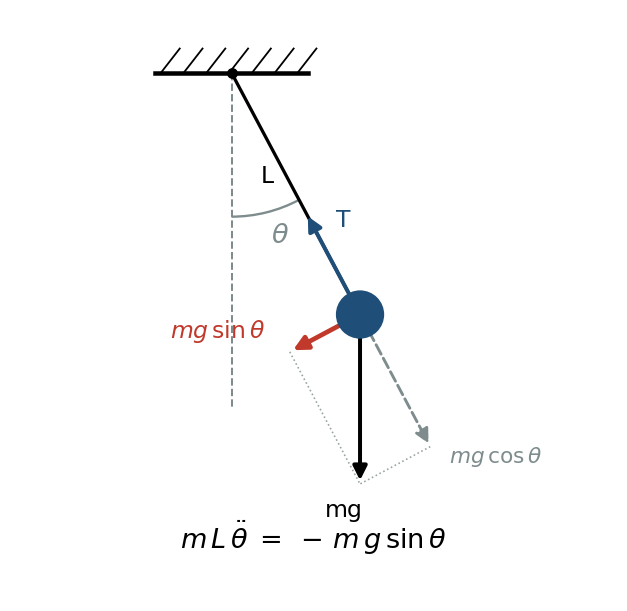

La segunda ley en esa dirección, con la aceleración escrita como $L\ddot\theta$,
queda

$$m\,L\,\ddot{\theta} = -m\,g\,\sin\theta$$

La masa se va de los dos lados, y por eso el período de un péndulo no depende de
cuánto pese. Nos queda

$$\ddot{\theta} = -\frac{g}{L}\,\sin\theta$$

El seno es el problema. Con el seno ahí adentro la ecuación es no lineal y no hay
manera de resolverla con lo que se enseña en secundaria. La salida de siempre es
suponer que el ángulo es chico: midiendo en radianes, $\sin\theta \approx \theta$,
con un error del 0.5 % a 10° y del 2 % a 20°. Reemplazando:

$$\ddot{\theta} = -\omega_0^2\,\theta, \qquad \omega_0 = \sqrt{g/L}$$

que es la misma ecuación que la del resorte, con la solución que todos conocemos:

$$\theta(t) = \theta_0\cos(\omega_0 t), \qquad T_0 = 2\pi\sqrt{L/g}$$

Vale la pena mirar con cuidado la fórmula del período. Aparecen $L$ y $g$; no
aparece $\theta_0$. Según esta cuenta, el péndulo tarda lo mismo en ir y venir si
lo sueltan desde 5° que si lo sueltan desde 90°. Esa propiedad se llama isocronía
y es la razón por la que un péndulo sirve para medir el tiempo. Se la atribuye a
Galileo, que según la historia la notó mirando oscilar una lámpara colgada en la
catedral de Pisa.

Galileo la creía exacta. No lo es, y en un rato vamos a ver cuánto se aparta.

In [ ]:
#@title Solución lineal θ(t) (doble click para ver el código) { display-mode: "form" }
s_L  = FloatSlider(min=0.2, max=2.0, step=0.05, value=1.0, description="L (m)",
                   continuous_update=True, readout_format=".2f")
s_th = IntSlider(min=1, max=170, value=15, description="θ₀ (grados)",
                 continuous_update=True)

fig, ax = lienzo(7.2, 4.0)
t = np.linspace(0, 8, 1200)
curva, = ax.plot([], [], lw=2.2, color="#1f4e79")
recta_T = ax.axvline(0, ls="--", lw=1.4, color="#c0392b")
texto_T = ax.text(0, 0, "", color="#c0392b", fontsize=10)
ax.axhline(0, color="gray", lw=0.6)
ax.set_xlim(0, 8); ax.set_xlabel("t (s)"); ax.set_ylabel("θ (rad)")

def dibujar(_=None):
    th0 = np.radians(s_th.value)
    w0  = np.sqrt(g/s_L.value)
    T0  = 2*np.pi/w0
    curva.set_data(t, th0*np.cos(w0*t))
    recta_T.set_xdata([T0, T0])
    ax.set_ylim(-1.15*th0, 1.15*th0)
    texto_T.set_position((T0 + 0.1, 0.95*th0))
    texto_T.set_text(f"un período = {T0:.3f} s")
    ax.set_title(f"θ(t) = θ₀·cos(ω₀t)     con L = {s_L.value:.2f} m "
                 f"y θ₀ = {s_th.value}°")
    fig.canvas.draw_idle()

for s in (s_L, s_th):
    s.observe(dibujar, names="value")
dibujar()
mostrar(fig, HBox([s_L, s_th]))

**Para probar:** muevan el ángulo inicial de 1° a 170°. La curva se hace más alta
pero no cambia de forma, y la raya roja del período no se mueve ni un poco. Con el
largo sí se mueve: cuadruplicar $L$ duplica el período.

Acuérdense de esto, porque es lo primero que vamos a romper.

---
## 2. Cómo se resuelve una ecuación que no se puede resolver

Si no queremos aproximar el seno, hay que integrar numéricamente. La idea es más
simple de lo que suena. La ecuación no nos regala $\theta(t)$, pero nos dice algo
casi tan útil: para cada estado del péndulo, cuánto está cambiando. Si sabemos
dónde estamos y hacia dónde vamos, podemos avanzar un poquito, volver a preguntar
y repetir.

El método más directo es el de **Euler**: avanzar en línea recta usando la
pendiente del punto en el que estamos.

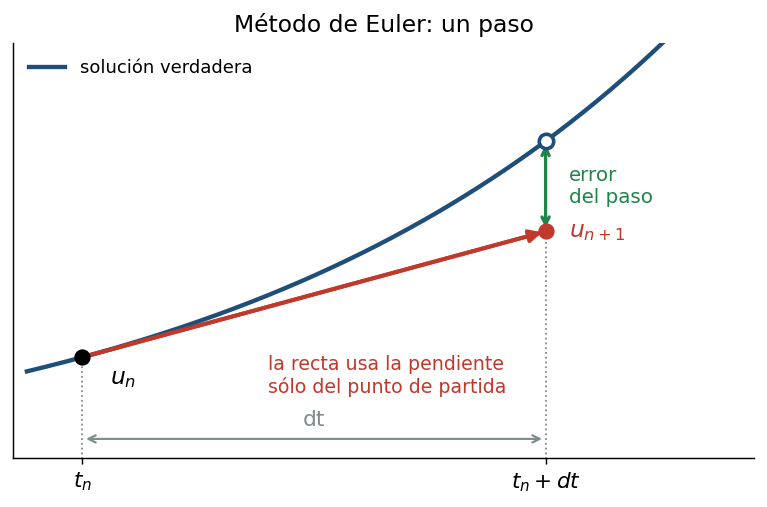

Ahí se ve el problema. La pendiente cambia a lo largo del paso y Euler usa la del
principio, así que el paso queda desviado y el error se acumula.

Hay dos maneras de mejorarlo. Una es usar pasos más chicos: siempre funciona y
siempre cuesta más tiempo de cálculo. La otra es preguntar la pendiente varias
veces dentro del mismo paso, que es la idea de **Runge–Kutta**. En la versión de
orden 4, la más usada, se hacen cuatro tanteos.

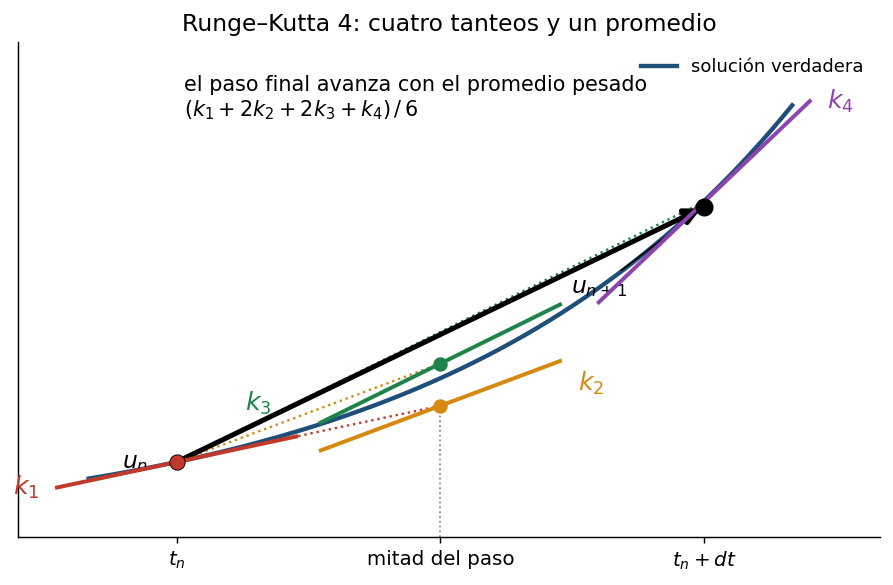

Se lee así: $k_1$ es la pendiente en el punto de partida, la misma que usaría
Euler. Con $k_1$ se avanza medio paso y ahí se vuelve a preguntar: eso es $k_2$.
Con $k_2$ se avanza medio paso otra vez desde el principio, y sale $k_3$. Con
$k_3$ se avanza el paso entero y al final se mide $k_4$. El paso de verdad se hace
con el promedio pesado $(k_1 + 2k_2 + 2k_3 + k_4)/6$, que le da el doble de peso a
las dos pendientes del medio.

Los dos métodos entran en pocas líneas, y no hay nada escondido adentro:

In [ ]:
def euler(f, u0, tmax, dt):
    "Integra una trayectoria con el método de Euler. u0 = [theta, omega]."
    n  = int(tmax/dt)
    ts = np.linspace(0, n*dt, n+1)
    us = np.zeros((n+1, len(u0)))
    us[0] = u0
    for i in range(n):
        us[i+1] = us[i] + dt*f(us[i], ts[i])
    return ts, us


def rk4(f, u0, tmax, dt):
    "Lo mismo con Runge-Kutta 4: cuatro tanteos por paso."
    n  = int(tmax/dt)
    ts = np.linspace(0, n*dt, n+1)
    us = np.zeros((n+1, len(u0)))
    us[0] = u0
    for i in range(n):
        u, t = us[i], ts[i]
        k1 = f(u,            t)
        k2 = f(u + dt/2*k1,  t + dt/2)
        k3 = f(u + dt/2*k2,  t + dt/2)
        k4 = f(u + dt*k3,    t + dt)
        us[i+1] = u + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    return ts, us

Falta decir qué es `f`. Los dos métodos están escritos para ecuaciones de primer
orden, y la del péndulo es de segundo. El truco de siempre: en vez de una ecuación
para $\theta$, dos ecuaciones para el par $(\theta, \omega)$, que es el estado
completo del péndulo.

$$\dot{\theta} = \omega, \qquad
\dot{\omega} = -\frac{g}{L}\sin\theta \;-\; b\,\omega$$

El término $-b\,\omega$ es el rozamiento, una fuerza que frena y es proporcional a
la velocidad. Lo vamos a dejar en cero hasta la sección 5.

In [ ]:
def pendulo(u, t, L=1.0, b=0.0):
    theta, omega = u
    return np.array([omega,
                     -(g/L)*np.sin(theta) - b*omega])

In [ ]:
#@title Los mismos dos métodos, compilados para las figuras interactivas { display-mode: "form" }
# Las mismas dos cuentas, compiladas con numba y escritas con números sueltos
# en vez de arreglos. Da exactamente lo mismo y es unas 50 veces más rápido,
# que es lo que hace que los deslizadores respondan mientras se arrastran.

@njit
def orbita_rk4(th0, om0, b, L, dt, pasos):
    th = np.empty(pasos + 1); om = np.empty(pasos + 1)
    th[0] = th0; om[0] = om0
    for i in range(pasos):
        x, v = th[i], om[i]
        a1, c1 = v,           -(g/L)*np.sin(x) - b*v
        a2, c2 = v + dt/2*c1, -(g/L)*np.sin(x + dt/2*a1) - b*(v + dt/2*c1)
        a3, c3 = v + dt/2*c2, -(g/L)*np.sin(x + dt/2*a2) - b*(v + dt/2*c2)
        a4, c4 = v + dt*c3,   -(g/L)*np.sin(x + dt*a3)   - b*(v + dt*c3)
        th[i+1] = x + dt/6*(a1 + 2*a2 + 2*a3 + a4)
        om[i+1] = v + dt/6*(c1 + 2*c2 + 2*c3 + c4)
    return th, om

@njit
def orbita_euler(th0, om0, b, L, dt, pasos):
    th = np.empty(pasos + 1); om = np.empty(pasos + 1)
    th[0] = th0; om[0] = om0
    for i in range(pasos):
        x, v = th[i], om[i]
        th[i+1] = x + dt*v
        om[i+1] = v + dt*(-(g/L)*np.sin(x) - b*v)
    return th, om

orbita_rk4(0.5, 0.0, 0.0, 1.0, 0.01, 10)      # primera llamada: compila
orbita_euler(0.5, 0.0, 0.0, 1.0, 0.01, 10)
print("integradores listos")

### Cuánto importa elegir bien el método

Los dos métodos son honestos: con pasos suficientemente chicos los dos dan lo
mismo. La diferencia está en cuánto hay que achicar el paso, y eso se ve mejor en
un caso donde sabemos qué tiene que pasar. Acá está el mismo péndulo, soltado
desde 90° y sin rozamiento, resuelto con los dos métodos.

A la izquierda, la órbita en el plano $(\theta, \omega)$: sin rozamiento la energía
se conserva, así que la curva tiene que cerrarse sobre sí misma y repasar siempre
por el mismo lugar. A la derecha, el error relativo de la energía, que mide cuánto
se aparta cada método de eso.

In [ ]:
#@title Euler contra RK4 en el mismo péndulo { display-mode: "form" }
s_dt   = SelectionSlider(options=[0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1],
                         value=0.005, description="dt (s)",
                         continuous_update=True)
s_tmax = IntSlider(min=5, max=40, step=5, value=10, description="t max (s)",
                   continuous_update=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
fig.canvas.header_visible = False
fig.canvas.toolbar_visible = False
fig.canvas.footer_visible = False

le_e, = ax1.plot([], [], lw=1.1, color="#c0392b", label="Euler")
le_r, = ax1.plot([], [], lw=1.6, color="#1f4e79", label="RK4")
ax1.plot([np.pi/2], [0], "k*", ms=12)
for x in (-np.pi, np.pi):
    ax1.axvline(x, ls=":", lw=1.1, color="gray")
ax1.set_xlabel("θ (rad)"); ax1.set_ylabel("ω (rad/s)")
ax1.set_title("la órbita tendría que cerrarse")
ax1.legend(loc="upper right", fontsize=9)

en_e, = ax2.plot([], [], lw=1.4, color="#c0392b", label="Euler")
en_r, = ax2.plot([], [], lw=1.4, color="#1f4e79", label="RK4")
ax2.set_yscale("log"); ax2.set_ylim(1e-16, 1e3)
ax2.set_xlabel("t (s)"); ax2.set_ylabel("error relativo de la energía")
ax2.set_title("cuánta energía se inventa cada método")
ax2.legend(loc="lower right", fontsize=9)

def energia(th, om):
    return 0.5*om**2 + g*(1 - np.cos(th))

def dibujar(_=None):
    dt, tmax = s_dt.value, float(s_tmax.value)
    pasos = int(tmax/dt)
    t = np.linspace(0, tmax, pasos + 1)
    th_e, om_e = orbita_euler(np.pi/2, 0.0, 0.0, 1.0, dt, pasos)
    th_r, om_r = orbita_rk4(np.pi/2, 0.0, 0.0, 1.0, dt, pasos)

    le_e.set_data(th_e, om_e); le_r.set_data(th_r, om_r)
    m = min(max(2.0, np.abs(th_e).max()*1.1), 6.5)
    w = min(max(5.0, np.abs(om_e).max()*1.1), 10.0)
    ax1.set_xlim(-m, m); ax1.set_ylim(-w, w)

    E0 = energia(np.pi/2, 0.0)
    en_e.set_data(t, np.maximum(np.abs(energia(th_e, om_e)/E0 - 1), 1e-17))
    en_r.set_data(t, np.maximum(np.abs(energia(th_r, om_r)/E0 - 1), 1e-17))
    ax2.set_xlim(0, tmax)

    er_e = abs(energia(th_e[-1], om_e[-1])/E0 - 1)
    er_r = abs(energia(th_r[-1], om_r[-1])/E0 - 1)
    fig.suptitle(f"dt = {dt} s     error final:  Euler {er_e:.1e}     "
                 f"RK4 {er_r:.1e}", fontsize=11)
    fig.canvas.draw_idle()

for s in (s_dt, s_tmax):
    s.observe(dibujar, names="value")
dibujar()
mostrar(fig, HBox([s_dt, s_tmax]))

**Para probar:**

1. Con los valores que vienen puestos (`dt = 0.005`), la órbita de Euler no se
   cierra: se va abriendo en espiral. El péndulo llega cada vez más alto, como si
   alguien le estuviera empujando. No hay ninguna física ahí, es el método
   inventando energía: en diez segundos se inventó más del 30 %.
2. Suban `dt` a 0.02 y Euler se escapa del todo. Cruza las rayas punteadas de
   $\pm\pi$, que es el péndulo pasando por arriba del punto de colgado: imposible,
   si lo soltamos en reposo desde 90° y nadie lo empuja.
3. RK4 mantiene la curva cerrada incluso con pasos grandes, y el panel derecho
   muestra por qué: con `dt = 0.02` su error de energía es de una parte en cinco
   millones.
4. Vayan bajando `dt` y mirando el panel derecho. Cada vez que el paso se divide
   por dos, el error de Euler se divide por dos: es un método de **orden 1**. RK4
   cae mucho más rápido, porque es de **orden 4**: dividir el paso por dos le
   divide el error de la trayectoria por dieciséis.
5. Suban `t max`. El error de Euler crece con el tiempo simulado; el de RK4
   también, pero desde tan abajo que no se nota.

De acá en adelante usamos RK4. Con `dt = 0.005` la energía del péndulo se conserva
con un error de una parte en mil millones, y con eso estamos más que cubiertos.

---
## 3. ¿Cuándo se rompe la aproximación?

Ahora podemos comparar sin trampa: la solución lineal, que sabemos escribir a
mano, contra la solución de la ecuación completa, que sale del integrador.

In [ ]:
#@title La solución exacta contra la lineal { display-mode: "form" }
s_th3 = IntSlider(min=1, max=179, value=20, description="θ₀ (grados)",
                  continuous_update=True)
s_L3  = FloatSlider(min=0.2, max=2.0, step=0.05, value=1.0, description="L (m)",
                    continuous_update=True, readout_format=".2f")

fig, ax = lienzo(8.0, 4.2)
DT, TMAX = 0.005, 12.0
PASOS = int(TMAX/DT)
t3 = np.linspace(0, TMAX, PASOS + 1)
l_num, = ax.plot([], [], lw=2.2, color="#1f4e79", label="ecuación completa")
l_lin, = ax.plot([], [], lw=1.8, ls="--", color="#c0392b",
                 label="aproximación lineal")
ax.axhline(0, color="gray", lw=0.6)
ax.set_xlim(0, TMAX); ax.set_xlabel("t (s)"); ax.set_ylabel("θ (rad)")
ax.legend(loc="lower left", fontsize=9)

def dibujar(_=None):
    th0 = np.radians(s_th3.value)
    L   = s_L3.value
    w0  = np.sqrt(g/L)
    th, _om = orbita_rk4(th0, 0.0, 0.0, L, DT, PASOS)
    l_num.set_data(t3, th)
    l_lin.set_data(t3, th0*np.cos(w0*t3))
    ax.set_ylim(-1.2*th0, 1.2*th0)
    ax.set_title(f"θ₀ = {s_th3.value}°     L = {L:.2f} m")
    fig.canvas.draw_idle()

for s in (s_th3, s_L3):
    s.observe(dibujar, names="value")
dibujar()
mostrar(fig, HBox([s_th3, s_L3]))

**Para probar:** empiecen en 10°, donde las dos curvas se superponen y no se
distinguen. Pasen a 45° y van a ver que se desfasan de a poco. En 170° no tienen
nada que ver.

Fíjense en qué falla y en qué no. La solución de la ecuación completa sigue siendo
periódica y perfectamente ordenada: no hay nada caótico acá. Lo que falla es el
valor del período, que resulta depender de la amplitud.

---
## 4. De dónde sale el período exacto

Para el período no hace falta resolver la ecuación: alcanza con la conservación de
la energía, que es una cuenta de secundaria. Si el péndulo se suelta en reposo
desde $\theta_0$, la energía cinética que tiene al pasar por un ángulo $\theta$ es
la potencial que perdió:

$$\tfrac{1}{2}m L^2\dot\theta^{\,2} = m g L\,(\cos\theta - \cos\theta_0)$$

Despejando la velocidad angular:

$$\dot\theta = \sqrt{\frac{2g}{L}}\;\sqrt{\cos\theta - \cos\theta_0}$$

Y acá viene el paso lindo. Como $\dot\theta = d\theta/dt$, podemos darlo vuelta y
pensar en cuánto tiempo tarda en recorrer cada pedacito de ángulo:

$$dt = \frac{d\theta}{\dot\theta}$$

Ir de $0$ a $\theta_0$ es un cuarto de período, así que el período entero es cuatro
veces la suma de todos esos pedacitos:

$$T(\theta_0) = 4\sqrt{\frac{L}{2g}}
\int_0^{\theta_0}\frac{d\theta}{\sqrt{\cos\theta - \cos\theta_0}}$$

Todo esto es exacto: no aproximamos nada. Lo que pasa es que esa integral no tiene
primitiva escribible con las funciones de siempre. Con un cambio de variable se la
puede poner en una forma estándar,

$$T(\theta_0) = 4\sqrt{\frac{L}{g}}\;
K\!\left(\sin^2\frac{\theta_0}{2}\right)$$

donde $K$ es la integral elíptica completa de primera especie. Es decir: hay
fórmula cerrada, pero está escrita con una función que hay que evaluar
numéricamente igual. La frontera que importa no es *tiene fórmula / no tiene
fórmula*, es qué preguntas podemos contestar con lo que tenemos.

<details>
<summary><b>El cambio de variable, para quien lo quiera ver</b></summary>

Usando $\cos\theta = 1 - 2\sin^2(\theta/2)$, el radicando queda
$2[\sin^2(\theta_0/2) - \sin^2(\theta/2)]$. Con la sustitución

$$\sin\frac{\theta}{2} = \sin\frac{\theta_0}{2}\,\sin\varphi$$

el ángulo $\theta = \theta_0$ pasa a ser $\varphi = \pi/2$, y después de simplificar
queda

$$T = 4\sqrt{\frac{L}{g}}\int_0^{\pi/2}
\frac{d\varphi}{\sqrt{1 - \sin^2(\theta_0/2)\,\sin^2\varphi}}$$

que es justamente la definición de $K$. Ojo con una trampa de notación: `scipy`
espera el parámetro $m = k^2$, o sea $\sin^2(\theta_0/2)$, no $\sin(\theta_0/2)$.

</details>

Para ángulos que no son enormes hay algo mucho más manejable. Desarrollando en
serie:

$$T \approx T_0\left(1 + \frac{\theta_0^2}{16}
+ \frac{11\,\theta_0^4}{3072} + \ldots\right)$$

Con el primer término ya alcanza para el aula: **el error relativo de la fórmula de
siempre es aproximadamente $\theta_0^2/16$, con $\theta_0$ en radianes.**

Abajo comparamos cuatro cosas: la predicción lineal (que dice que $T$ no cambia),
la fórmula elíptica, esta serie, y el período **medido** sobre la simulación
buscando cuándo el péndulo vuelve a pasar por donde arrancó.

In [ ]:
def T_exacto(theta0, L=1.0):
    "Período por la integral elíptica. Ojo: scipy usa el parámetro m = k²."
    return 4*np.sqrt(L/g)*ellipk(np.sin(theta0/2)**2)


def T_serie(theta0, L=1.0):
    "Los dos primeros términos del desarrollo."
    T0 = 2*np.pi*np.sqrt(L/g)
    return T0*(1 + theta0**2/16 + 11*theta0**4/3072)


def periodo_medido(theta0, L=1.0, dt=1e-3):
    "Mide el período buscando dos pasajes consecutivos por ω = 0 subiendo."
    ts, us = rk4(lambda u, t: pendulo(u, t, L=L),
                 [theta0, 0.0], 6*2*np.pi*np.sqrt(L/g), dt)
    w = us[:, 1]
    cruces = []
    for i in range(1, len(ts)):
        if w[i-1] < 0 <= w[i]:                 # cambio de signo − → +
            a = -w[i-1]/(w[i] - w[i-1])        # interpolación lineal
            cruces.append(ts[i-1] + a*dt)
            if len(cruces) == 2:
                break
    return cruces[1] - cruces[0] if len(cruces) == 2 else np.nan

In [ ]:
#@title El período contra la amplitud { display-mode: "form" }
T0 = 2*np.pi*np.sqrt(1.0/g)
th_curva = np.radians(np.arange(1, 176, 2))
th_pts   = np.radians(np.arange(10, 171, 20))

fig, ax = lienzo(7.6, 4.6)
ax.plot(np.degrees(th_curva), [T_exacto(t)/T0 for t in th_curva],
        lw=2.5, color="#1f4e79", label="fórmula elíptica")
ax.plot(np.degrees(th_curva), [T_serie(t)/T0 for t in th_curva],
        lw=1.8, ls="-.", color="#1e8449", label="serie, dos términos")
ax.axhline(1, ls="--", color="gray", label="predicción lineal")
ax.plot(np.degrees(th_pts), [periodo_medido(t)/T0 for t in th_pts],
        "o", ms=8, color="#c0392b", zorder=5, label="medido en la simulación")
ax.set_xlabel("θ₀ (grados)"); ax.set_ylabel("T(θ₀) / T₀")
ax.set_ylim(0.95, 3.0)
ax.set_title("El período sí depende de la amplitud")
ax.legend(loc="upper left", fontsize=9)
mostrar(fig)

Los puntos rojos caen exactamente sobre la curva azul: la fórmula elíptica y la
simulación coinciden, con un error relativo del orden de $10^{-13}$. Son dos
caminos independientes que dan el mismo número, y eso es lo que nos deja confiar en
el integrador para lo que viene, donde no va a haber fórmula con la que comparar.

La serie acompaña bien hasta unos 60° y después se despega, como corresponde. La
recta gris es lo que predice la aproximación lineal, y se va quedando cada vez más
corta: a 170° el período real es más del doble.

**Ejercicio 1.** ¿A partir de qué amplitud el error de la aproximación lineal
supera el 1 %?

Se puede sacar a mano con la serie: el error relativo es $\theta_0^2/16$, así que
igualando a 0.01 queda $\theta_0 = 0.4$ radianes. Pasen eso a grados y prueben el
valor en la celda de abajo, cambiando el número y ejecutando con Shift+Enter.

In [ ]:
theta_prueba = 20      # ←←← CAMBIAR ESTE NÚMERO (en grados)

# ---- de acá para abajo no hace falta tocar nada ----
err = 100*(T_exacto(np.radians(theta_prueba))/T0 - 1)
print(f"Con θ₀ = {theta_prueba}° el período real es un {err:.2f} % más largo")
print(f"que el que predice la fórmula lineal.")

> **Para el aula:** ese número explica por qué los relojes de péndulo trabajan con
> amplitudes chicas, y por qué en el laboratorio conviene medir $T$ con
> $\theta_0 < 15°$ si lo que se quiere verificar es $T = 2\pi\sqrt{L/g}$. También
> da una medición linda: soltar el mismo péndulo desde 10° y desde 60° y cronometrar
> diez oscilaciones de cada una. La diferencia es del 7 % y se mide sin
> instrumental.

---
## 5. El espacio de fases

Hasta ahora miramos $\theta$ contra $t$, una curva por cada condición inicial. Hay
otra forma de mirar lo mismo que resulta mucho más económica: como el estado del
péndulo son dos números, $(\theta, \omega)$, cada estado es **un punto** en un
plano y la evolución del péndulo es **una curva** en ese plano. Todo el
comportamiento posible del sistema entra en un solo dibujo.

Las flechas grises son el campo de direcciones, y salen de las ecuaciones sin
resolver nada. En un punto cualquiera $(\theta, \omega)$ las ecuaciones dicen
cuánto está cambiando cada coordenada:

$$\dot\theta = \omega, \qquad
\dot\omega = -\frac{g}{L}\sin\theta - b\,\omega$$

Esos dos números son las componentes de la flecha en ese punto. Por ejemplo, con
$L = 1$ y sin rozamiento:

- en $(\pi/2,\; 0)$, o sea el péndulo horizontal y quieto: $\dot\theta = 0$ y
  $\dot\omega = -9.8$. La flecha apunta derecho hacia abajo, porque el péndulo
  todavía no se mueve pero está a punto de acelerar.
- en $(0,\; 3)$, el péndulo pasando por abajo a toda velocidad: $\dot\theta = 3$ y
  $\dot\omega = 0$. La flecha apunta a la derecha, horizontal.
- en $(0,\; 0)$, el péndulo colgando quieto: las dos derivadas son cero. No hay
  flecha, porque no pasa nada. Es un punto de equilibrio.

Las flechas están todas dibujadas del mismo largo para que se vean parejas; acá lo
único que nos interesa es la dirección. Una trayectoria es una curva que en cada
punto va para donde apunta la flecha, así que integrar es seguir las flechas.

**Hacé click adentro del gráfico** para soltar un péndulo desde ese estado. El
deslizador de rozamiento rehace todas las trayectorias que hayas puesto.

In [ ]:
#@title Espacio de fases: click para soltar un péndulo { display-mode: "form" }
s_b = FloatSlider(min=0.0, max=1.0, step=0.02, value=0.0,
                  description="b (roce)", continuous_update=True,
                  readout_format=".2f")
b_borrar = Button(description="borrar trayectorias")
aviso = Label("hacé click adentro del gráfico")

fig, ax = lienzo(8.2, 5.0, barra=True)
TH, OM = np.meshgrid(np.linspace(-3*np.pi, 3*np.pi, 25),
                     np.linspace(-8, 8, 17))

def direcciones(b):
    U = OM
    V = -g*np.sin(TH) - b*OM
    n = np.hypot(U, V) + 1e-9
    return U/n, V/n

flechas = ax.quiver(TH, OM, *direcciones(0.0), color="gray", alpha=0.45,
                    width=0.0022)

# separatriz sin rozamiento: la frontera entre oscilar y dar vueltas
th_sep = np.linspace(-3*np.pi, 3*np.pi, 800)
sep_sup = 2*np.sqrt(g)*np.cos(th_sep/2)
ax.plot(th_sep, sep_sup, ls=":", lw=1.2, color="#8e44ad")
ax.plot(th_sep, -sep_sup, ls=":", lw=1.2, color="#8e44ad")

# equilibrios: estables abajo, inestables arriba
ax.plot([-2*np.pi, 0, 2*np.pi], [0, 0, 0], "o", ms=7, color="black")
ax.plot([-3*np.pi, -np.pi, np.pi, 3*np.pi], [0, 0, 0, 0], "x", ms=9,
        color="black", mew=2)

ax.set_xlim(-3*np.pi, 3*np.pi); ax.set_ylim(-8, 8)
ax.set_xticks(np.pi*np.arange(-3, 4))
ax.set_xticklabels(["-3π", "-2π", "-π", "0", "π", "2π", "3π"])
ax.set_xlabel("θ (rad)"); ax.set_ylabel("ω (rad/s)")
ax.set_title("Espacio de fases del péndulo")

CI, lineas, marcas = [], [], []
DT5, PASOS5 = 0.02, 1800

def rehacer(_=None):
    b = s_b.value
    flechas.set_UVC(*direcciones(b))
    for (th0, om0), ln in zip(CI, lineas):
        th, om = orbita_rk4(th0, om0, b, 1.0, DT5, PASOS5)
        ln.set_data(th, om)
    fig.canvas.draw_idle()

def al_click(ev):
    if ev.inaxes is not ax or ev.button != 1:
        return
    barra = getattr(fig.canvas, "toolbar", None)
    if barra is not None and getattr(barra, "mode", ""):
        return                                  # con la lupa activa no suelta nada
    CI.append((ev.xdata, ev.ydata))
    th, om = orbita_rk4(ev.xdata, ev.ydata, s_b.value, 1.0, DT5, PASOS5)
    lineas.append(ax.plot(th, om, lw=1.4)[0])
    marcas.append(ax.plot([ev.xdata], [ev.ydata], "o", ms=4, color="black")[0])
    aviso.value = f"{len(CI)} trayectorias   (último click en θ = {ev.xdata:.2f})"
    fig.canvas.draw_idle()

def borrar(_):
    for art in lineas + marcas:
        art.remove()
    lineas.clear(); marcas.clear(); CI.clear()
    aviso.value = "hacé click adentro del gráfico"
    fig.canvas.draw_idle()

fig.canvas.mpl_connect("button_press_event", al_click)
s_b.observe(rehacer, names="value")
b_borrar.on_click(borrar)
mostrar(fig, HBox([s_b, b_borrar]), aviso)

**Para probar, en este orden:**

1. Con $b = 0$, hagan click cerca del origen. Sale una curva cerrada: el péndulo
   oscila y vuelve siempre al mismo estado. Cuanto más lejos del origen, más grande
   la curva.
2. Ahora click arriba, con $\omega$ grande, cerca del borde superior. La curva ya
   no se cierra: atraviesa la pantalla de izquierda a derecha, porque el péndulo
   tiene tanta energía que da vueltas enteras y $\theta$ crece sin parar.
3. La curva punteada violeta separa los dos comportamientos y se llama
   **separatriz**. Pasa por las cruces, que son los equilibrios inestables: el
   péndulo parado justo cabeza arriba en $\theta = \pm\pi$. Hagan click apenas por
   debajo y apenas por encima de la punteada y comparen.
4. Prueben clickear en varios lugares. Las curvas nunca se cruzan entre sí, y eso
   no es casualidad: si dos trayectorias pasaran por el mismo punto, ese punto
   tendría dos futuros distintos, y las ecuaciones dan uno solo.
5. Suban el rozamiento a 0.3 y miren cómo se rehace todo. Ahora las curvas se
   enroscan hacia el origen. El reposo pasó a ser un **atractor**: no importa desde
   dónde se suelte, el péndulo termina ahí.

Guarden esta idea porque es la que necesitamos para lo que viene: **sin disipación
no hay atractores**, sólo órbitas que conservan la energía y se repiten para
siempre. Cuando hay rozamiento, en cambio, aparecen estados finales a los que el
sistema va a parar, y entonces tiene sentido preguntarse *a cuál*.

---
## 6. El péndulo magnético

Un péndulo con un imán en la punta, colgado de un hilo largo, oscilando sobre una
mesa donde hay seis imanes fijos. Se consigue armado como juguete de escritorio,
cuesta poco y no tiene solución analítica.

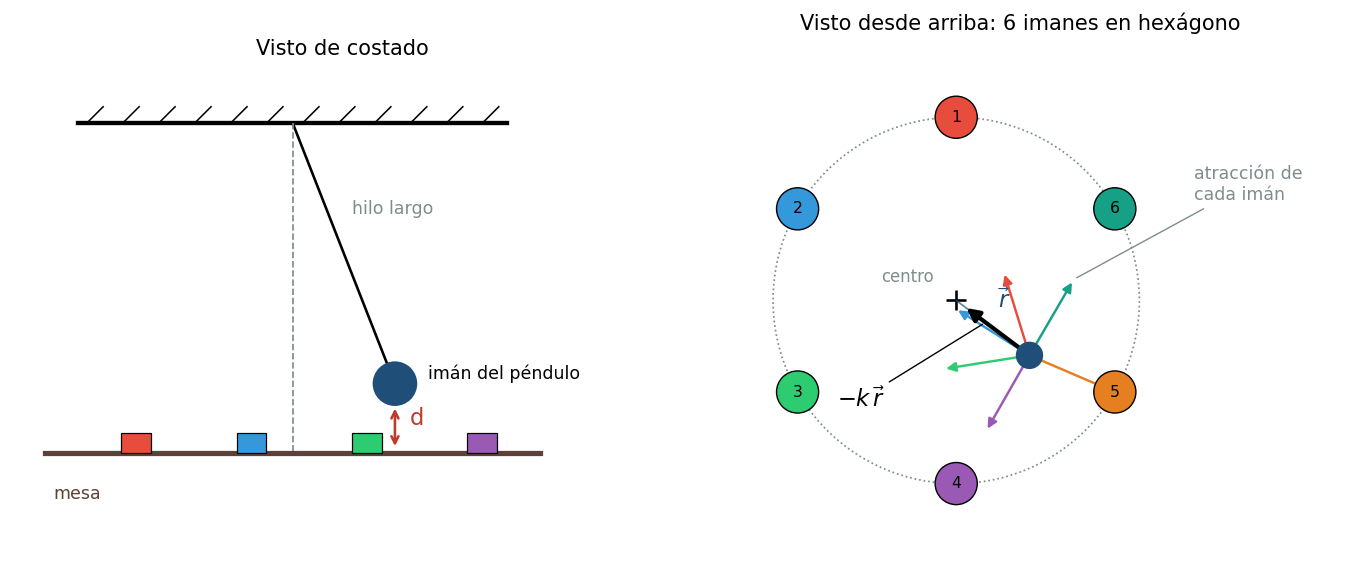

Si el hilo es largo y las oscilaciones no son enormes, el imán del péndulo se mueve
casi en un plano, y el modelo es un punto $(x, y)$ con tres cosas tirando de él:

- una fuerza hacia el centro, $-k\,\vec{r}$, que es la gravedad actuando a través
  del hilo (el mismo $-\theta$ de la aproximación lineal, ahora en dos dimensiones);
- rozamiento, $-b\,\vec{v}$, que frena: el aire, el hilo, todo junto;
- la atracción de cada imán, que es más fuerte cuanto más cerca está:

$$\sum_{i=1}^{6} \frac{\vec{r}_i - \vec{r}}
{\left(|\vec{r}_i - \vec{r}|^2 + d^2\right)^{3/2}}$$

Ese $d$ que aparece sumado es la altura a la que pasa el imán del péndulo sobre la
mesa, y hace dos cosas a la vez: es física, porque el imán pasa por encima y no
exactamente sobre el otro, y además evita que la fuerza se vuelva infinita cuando
el péndulo pasa justo sobre un imán.

Con rozamiento, toda trayectoria termina detenida sobre alguno de los seis imanes.
O sea que ahora hay **seis atractores** compitiendo. Y la pregunta interesante ya
no es dónde termina, que sabemos, sino en cuál de los seis según dónde lo soltamos.

In [ ]:
# los seis imanes, en los vértices de un hexágono de radio 1
ANG      = np.pi/2 + 2*np.pi*np.arange(6)/6
IMANES_X = np.cos(ANG)
IMANES_Y = np.sin(ANG)

K_RES = 0.5      # cuánto tira el hilo hacia el centro
D_ALT = 0.25     # altura del imán del péndulo sobre la mesa


def aceleracion(x, y, vx, vy, b):
    "Las tres fuerzas, sumadas. Es toda la física del sistema."
    ax = -K_RES*x - b*vx
    ay = -K_RES*y - b*vy
    for i in range(6):
        dx = IMANES_X[i] - x
        dy = IMANES_Y[i] - y
        r3 = (dx*dx + dy*dy + D_ALT*D_ALT)**1.5
        ax += dx/r3
        ay += dy/r3
    return ax, ay

In [ ]:
#@title El integrador del péndulo magnético { display-mode: "form" }
aceleracion = njit(aceleracion)     # compilamos la física de arriba

@njit
def sueltas(x0, y0, paso, n, b, dt=0.02, pasos=10000, cada=5):
    """Suelta n péndulos en reposo, repartidos sobre un segmento, y devuelve
    las trayectorias y el imán en el que terminó cada uno. Cada trayectoria
    se corta apenas se detiene, así que no se pierde tiempo de más."""
    guardados = pasos//cada + 1
    X = np.full((n, guardados), np.nan)
    Y = np.full((n, guardados), np.nan)
    destino = np.zeros(n, dtype=np.int64)

    for j in range(n):
        x = x0 + j*paso; y = y0
        vx = 0.0; vy = 0.0
        X[j, 0] = x; Y[j, 0] = y
        m = 1
        for i in range(pasos):
            a1, e1 = aceleracion(x, y, vx, vy, b)
            a2, e2 = aceleracion(x + dt/2*vx, y + dt/2*vy,
                                 vx + dt/2*a1, vy + dt/2*e1, b)
            a3, e3 = aceleracion(x + dt/2*(vx + dt/2*a1),
                                 y + dt/2*(vy + dt/2*e1),
                                 vx + dt/2*a2, vy + dt/2*e2, b)
            a4, e4 = aceleracion(x + dt*(vx + dt/2*a2),
                                 y + dt*(vy + dt/2*e2),
                                 vx + dt*a3, vy + dt*e3, b)
            x  += dt*(vx + dt/6*(a1 + a2 + a3))
            y  += dt*(vy + dt/6*(e1 + e2 + e3))
            vx += dt/6*(a1 + 2*a2 + 2*a3 + a4)
            vy += dt/6*(e1 + 2*e2 + 2*e3 + e4)
            if (i + 1) % cada == 0:
                X[j, m] = x; Y[j, m] = y
                m += 1
            if (i + 1) % 100 == 0:                     # ¿ya se detuvo?
                cerca = 9e9
                for k in range(6):
                    d2 = (x - IMANES_X[k])**2 + (y - IMANES_Y[k])**2
                    if d2 < cerca:
                        cerca = d2
                if (vx*vx + vy*vy) < 1e-6 and cerca < 0.16:
                    break
        mejor = 0; cerca = 9e9
        for k in range(6):
            d2 = (x - IMANES_X[k])**2 + (y - IMANES_Y[k])**2
            if d2 < cerca:
                cerca = d2; mejor = k
        destino[j] = mejor
    return X, Y, destino

sueltas(0.3, -1.4, 1e-3, 2, 0.1, pasos=200)      # primera llamada: compila
print("listo")

### Quince sueltas casi iguales

Soltamos quince péndulos en reposo, desde puntos repartidos sobre un segmentito de
largo $\delta$. El color de cada trayectoria dice en qué imán terminó.

La estrella está puesta a propósito sobre el borde entre dos cuencas: la busqué por
bisección, moviendo el punto de partida hasta encontrar el lugar exacto donde el
destino cambia de imán. En un punto cualquiera de la mesa la sensibilidad se agota
mucho antes.

In [ ]:
#@title Quince sueltas casi iguales { display-mode: "form" }
COLORES = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6", "#e67e22", "#16a085"]
X_BORDE, Y_BORDE = 0.310096746049, -1.40      # sobre el borde, con b = 0.10

s_delta = SelectionSlider(
    options=[("0.1", 1e-1), ("0.01", 1e-2), ("0.001", 1e-3),
             ("0.0001", 1e-4), ("0.00001", 1e-5), ("0.000001", 1e-6)],
    value=1e-3, description="δ", continuous_update=True)
s_b6 = FloatSlider(min=0.05, max=0.30, step=0.01, value=0.10,
                   description="b (roce)", continuous_update=True,
                   readout_format=".2f")
s_n = IntSlider(min=2, max=25, value=15, description="sueltas",
                continuous_update=True)
reparto = Label("")

fig, ax = lienzo(6.6, 6.6)
for i in range(6):
    ax.plot(IMANES_X[i], IMANES_Y[i], "o", ms=17, color=COLORES[i],
            mec="k", mew=1.0, zorder=5)
    ax.annotate(str(i+1), (IMANES_X[i], IMANES_Y[i]), ha="center",
                va="center", fontsize=9, zorder=6)
ax.plot(X_BORDE, Y_BORDE, "k*", ms=14, zorder=7)
ax.set_aspect("equal"); ax.set_xlim(-1.85, 1.85); ax.set_ylim(-1.85, 1.85)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.grid(alpha=0.2)
trazos = []

def dibujar(_=None):
    global trazos
    for t in trazos:
        t.remove()
    delta, n = s_delta.value, s_n.value
    X, Y, destino = sueltas(X_BORDE - delta/2, Y_BORDE, delta/(n - 1), n,
                            s_b6.value)
    trazos = [ax.plot(X[j], Y[j], lw=0.8, alpha=0.85,
                      color=COLORES[destino[j]])[0] for j in range(n)]
    cuenta = np.bincount(destino, minlength=6)
    cuantos = len(np.nonzero(cuenta)[0])
    final = "un solo imán" if cuantos == 1 else f"{cuantos} imanes distintos"
    ax.set_title(f"δ = {delta:.0e}     las {n} sueltas terminan en {final}")
    reparto.value = "   ".join(f"imán {i+1}: {c}"
                               for i, c in enumerate(cuenta) if c)
    fig.canvas.draw_idle()

for s in (s_delta, s_b6, s_n):
    s.observe(dibujar, names="value")
dibujar()
mostrar(fig, HBox([s_delta, s_n]), HBox([s_b6, reparto]))

**Para probar:** bajen $\delta$ de 0.1 hasta 0.000001, o sea de un décimo a una
millonésima. Con $\delta = 0.001$ las quince trayectorias se reparten entre los
seis imanes; con $\delta$ de una millonésima siguen sin ponerse de acuerdo, ahora
entre dos. Quince péndulos soltados en un segmento del ancho de un pelo terminan en
imanes distintos.

Fíjense en el detalle más lindo del dibujo: con $\delta$ chico las quince curvas se
dibujan una encima de otra y se ven como **una sola línea**. Van juntas durante
todo el recorrido y se separan recién al final, cuando cada una cae en su imán.

Ningún experimentalista controla la condición inicial con esa precisión. El
resultado es, en la práctica, **impredecible, aunque el sistema sea perfectamente
determinista**. Ésta es la frase del día:

> Determinista no es lo mismo que predecible.

Después prueben subir el rozamiento a 0.30. Las quince trayectorias se van juntas
al mismo imán, casi sin dar vueltas. Con más rozamiento el péndulo se frena antes
de poder deambular, y el destino se vuelve predecible: pasan dos cosas a la vez, el
borde entre cuencas se corrió (nuestra estrella ya no está sobre él) y las cuencas
se volvieron regiones grandes y simples.

O sea que la sensibilidad no es una propiedad del sistema entero. Depende de dónde
lo soltamos y de cuánto alcanza a recorrer antes de frenarse. Con poco rozamiento
el péndulo pasa varias veces cerca de varios imanes antes de decidirse, y por dónde
pase depende críticamente de dónde salió.

---
## 7. Para llevarse

| Sistema | ¿Hay fórmula? | ¿Es predecible? |
|---|---|---|
| Péndulo linealizado | sí, elemental | sí |
| Péndulo exacto | sí, con funciones elípticas | sí |
| Péndulo con rozamiento | no | sí |
| Péndulo magnético | no | **no, en la práctica** |

Tres ideas para cerrar el día:

1. **La no linealidad sola no produce caos.** El péndulo exacto es no lineal y es
   perfectamente regular: sacamos su período con una integral elíptica y lo
   verificamos contra la simulación con trece cifras. No linealidad no es sinónimo
   de desorden.

2. **Hace falta algo más.** En el péndulo magnético ese algo son los seis
   atractores compitiendo: el sistema tiene que elegir, y la elección depende de
   detalles cada vez más finos de la condición inicial. La otra receta clásica es
   energía entrando y saliendo: el mismo péndulo de la sección 5, empujado
   periódicamente y con rozamiento, también se vuelve caótico.

3. **Determinista no es predecible.** En las ecuaciones del péndulo magnético no
   hay ninguna aleatoriedad: seis imanes, un hilo y rozamiento. Y aun así no
   podemos anticipar dónde termina, porque no podemos fijar la condición inicial
   con precisión infinita.

> **Para el aula:** el péndulo magnético es un objeto de escritorio y la
> demostración lleva treinta segundos delante de la clase. Se lo suelta dos veces
> "desde el mismo lugar" y termina en imanes distintos. La pregunta *¿por qué no se
> puede repetir el experimento?* abre todo el tema, y no necesita ni una ecuación
> para plantearse.

**Mañana** empezamos con la calculadora en la mano, sin computadora. Vamos a ver
que para tener este comportamiento no hace falta ni una ecuación diferencial:
alcanza con una parábola y veinte multiplicaciones. Y escondido adentro hay un
número universal.